# 04 — Threshold Tuning and Regularization

### Project: Online Retail Engagement Risk Prediction
### Notebook: 04_threshold_tuning_and_regularization.ipynb

**Goals:**
- Identify optimal classification thresholds for specific business scenarios
- Compare L1, L2, and ElasticNet regularization across a range of C values
- Confirm the baseline model is well-calibrated and not overfitting
- Identify redundant features through L1 automatic feature selection

**Inputs:**
- `data/processed/lr_test_predictions.parquet` — test set predictions from notebook 03
- `data/processed/modeling_dataset.parquet` — full modeling dataset for regularization

**Outputs:**
- `models/churn_model_l1.pkl` — best L1 logistic regression model

**Steps:**
- Load test predictions and rebuild train/test split
- Plot precision-recall and ROC curves
- Sweep thresholds and identify three business operating points
- Compare L1, L2, and ElasticNet across six orders of magnitude of C
- Plot coefficient stability paths for all three penalty types
- Identify features zeroed out by L1 and validate against VIF findings
- Persist best L1 model to disk

In [16]:
# ─────────────────────────────────────────────────────────────
# Imports and Data Load
# ─────────────────────────────────────────────────────────────

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from pathlib import Path

from sklearn.pipeline        import Pipeline
from sklearn.preprocessing   import StandardScaler
from sklearn.linear_model    import LogisticRegression
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    roc_curve,
)

DATA_PATH = Path("../data/processed")

# Test predictions from notebook 03
eval_df    = pd.read_parquet(DATA_PATH / "lr_test_predictions.parquet")
y_test     = eval_df["y_true"]
proba_test = eval_df["p_churn"]

# Full modeling dataset for regularization section
model_df   = pd.read_parquet(DATA_PATH / "modeling_dataset.parquet")
model_df["snapshot_date"] = pd.to_datetime(model_df["snapshot_date"])

base_rate = y_test.mean()

print("Test set shape:  ", eval_df.shape)
print("Base churn rate: ", base_rate.round(4))

Test set shape:   (36552, 2)
Base churn rate:  0.6894


## Part 1 — Threshold Tuning
---

### Precision-Recall and ROC Curves

The precision-recall curve plots every possible classification threshold 
simultaneously. Each point on the curve represents a specific threshold value 
and shows the precision and recall the model achieves at that threshold.

- Moving **right** along the curve (higher recall) means lowering the threshold 
  — catching more churners but accepting more false positives
- Moving **left** along the curve (higher precision) means raising the threshold 
  — being more selective but missing more true churners

The ROC curve plots the same tradeoff from a different angle: true positive rate 
(recall) vs. false positive rate. A model hugging the top-left corner is 
near-perfect; a model following the diagonal is no better than random.

The current default operating point (threshold = 0.5) is marked on both curves.

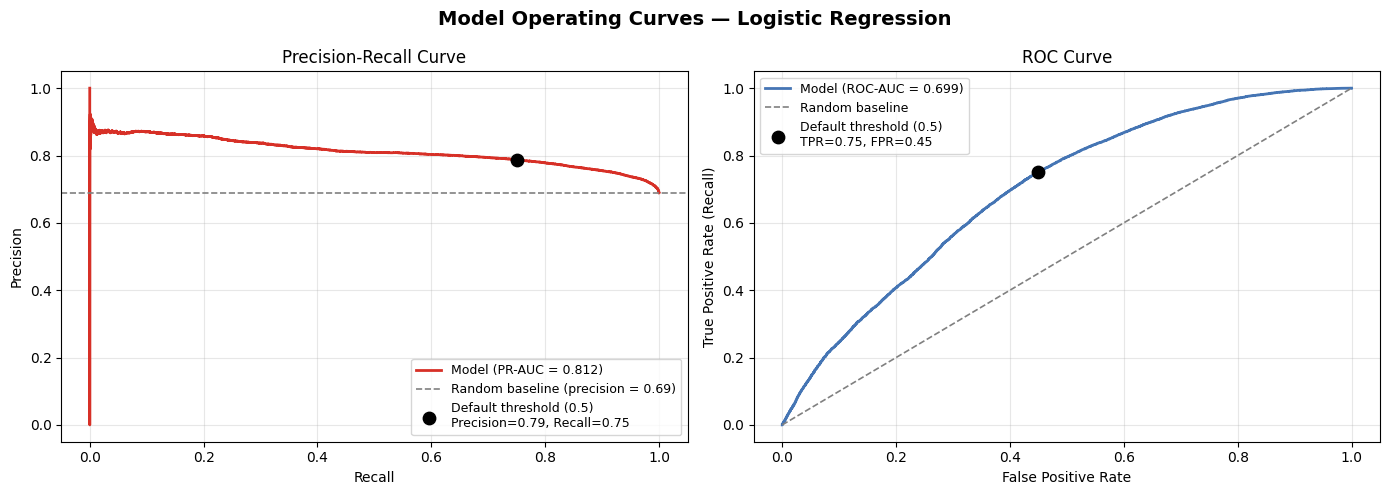

In [17]:
# ─────────────────────────────────────────────────────────────
# Precision-Recall Curve and ROC Curve
# ─────────────────────────────────────────────────────────────

precision_vals, recall_vals, pr_thresholds = precision_recall_curve(y_test, proba_test)
fpr_vals, tpr_vals, roc_thresholds = roc_curve(y_test, proba_test)

# Find index closest to default 0.5 threshold on PR curve
default_idx = np.argmin(np.abs(pr_thresholds - 0.5))
default_precision = precision_vals[default_idx]
default_recall = recall_vals[default_idx]

# Find index closest to 0.5 on ROC curve
roc_default_idx = np.argmin(np.abs(roc_thresholds - 0.5))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Model Operating Curves — Logistic Regression", fontsize=14, fontweight="bold")

# ── Left: Precision-Recall Curve ─────────────────────────────
ax1 = axes[0]
ax1.plot(recall_vals, precision_vals, color="#d73027", linewidth=2,
         label=f"Model (PR-AUC = {average_precision_score(y_test, proba_test):.3f})")
ax1.axhline(base_rate, linestyle="--", color="gray", linewidth=1.2,
            label=f"Random baseline (precision = {base_rate:.2f})")
ax1.scatter(default_recall, default_precision, color="black", zorder=5, s=80,
            label=f"Default threshold (0.5)\nPrecision={default_precision:.2f}, Recall={default_recall:.2f}")
ax1.set_xlabel("Recall")
ax1.set_ylabel("Precision")
ax1.set_title("Precision-Recall Curve")
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

# ── Right: ROC Curve ──────────────────────────────────────────
ax2 = axes[1]
ax2.plot(fpr_vals, tpr_vals, color="#4575b4", linewidth=2,
         label=f"Model (ROC-AUC = {roc_auc_score(y_test, proba_test):.3f})")
ax2.plot([0, 1], [0, 1], linestyle="--", color="gray", linewidth=1.2,
         label="Random baseline")
ax2.scatter(fpr_vals[roc_default_idx], tpr_vals[roc_default_idx],
            color="black", zorder=5, s=80,
            label=f"Default threshold (0.5)\nTPR={tpr_vals[roc_default_idx]:.2f}, FPR={fpr_vals[roc_default_idx]:.2f}")
ax2.set_xlabel("False Positive Rate")
ax2.set_ylabel("True Positive Rate (Recall)")
ax2.set_title("ROC Curve")
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Threshold Sweep

Sweeping thresholds from 0.1 to 0.9 and computing precision, recall, and F1 
at each point allows us to identify:

- **Max F1 threshold:** The point where precision and recall are best balanced
- **High recall threshold:** The lowest threshold that still catches ~90% of 
  churners — appropriate for low-cost outreach scenarios
- **High precision threshold:** The lowest threshold that achieves ~85% precision 
  — appropriate for budget-constrained or high-touch outreach scenarios

F1 is the harmonic mean of precision and recall. Unlike a simple average, the 
harmonic mean penalizes extreme imbalances — a model that catches everyone 
(recall=1.0) but is wrong half the time (precision=0.5) gets an F1 of 0.67, 
not 0.75. This makes F1 a more honest single-number summary of the tradeoff.

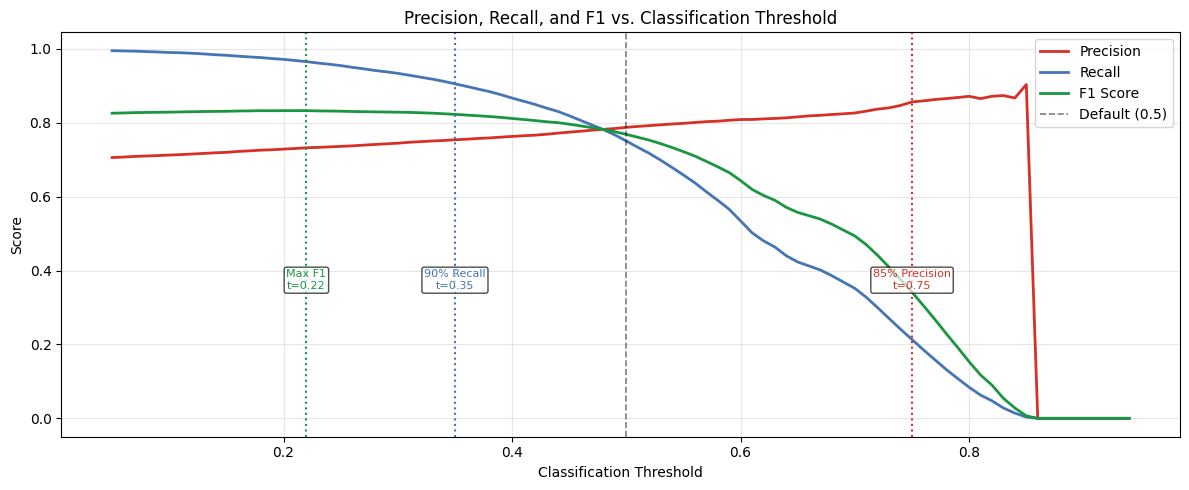

In [18]:
# ─────────────────────────────────────────────────────────────
# Threshold Sweep — Precision, Recall, F1 vs. Threshold
# ─────────────────────────────────────────────────────────────

thresholds = np.arange(0.05, 0.95, 0.01)

results = []
for t in thresholds:
    preds = (proba_test >= t).astype(int)
    results.append({
        "threshold": t,
        "precision": precision_score(y_test, preds, zero_division=0),
        "recall":    recall_score(y_test, preds, zero_division=0),
        "f1":        f1_score(y_test, preds, zero_division=0),
        "n_flagged": preds.sum(),
        "pct_flagged": preds.mean(),
    })

sweep_df = pd.DataFrame(results)

# ── Identify key thresholds ───────────────────────────────────

# 1. Max F1
max_f1_idx = sweep_df["f1"].idxmax()
max_f1_row = sweep_df.loc[max_f1_idx]

# 2. High recall: highest threshold that still achieves >= 90% recall
high_recall_row = (
    sweep_df[sweep_df["recall"] >= 0.90]
    .sort_values("threshold", ascending=False)
    .iloc[0]
)

# 3. High precision: lowest threshold that achieves >= 85% precision
high_precision_row = (
    sweep_df[sweep_df["precision"] >= 0.85]
    .sort_values("threshold", ascending=True)
    .iloc[0]
)

# ── Plot ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(sweep_df["threshold"], sweep_df["precision"], label="Precision",
        color="#d73027", linewidth=2)
ax.plot(sweep_df["threshold"], sweep_df["recall"], label="Recall",
        color="#4575b4", linewidth=2)
ax.plot(sweep_df["threshold"], sweep_df["f1"], label="F1 Score",
        color="#1a9641", linewidth=2)

# Mark the three key thresholds
for row, label, color in [
    (max_f1_row,        "Max F1",          "#1a9641"),
    (high_recall_row,   "90% Recall",      "#4575b4"),
    (high_precision_row,"85% Precision",   "#d73027"),
]:
    ax.axvline(row["threshold"], linestyle=":", color=color, linewidth=1.5)
    ax.annotate(f'{label}\nt={row["threshold"]:.2f}',
                xy=(row["threshold"], 0.35),
                fontsize=8, color=color,
                ha="center",
                bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.7))

ax.axvline(0.5, linestyle="--", color="black", linewidth=1.2, alpha=0.5,
           label="Default (0.5)")
ax.set_xlabel("Classification Threshold")
ax.set_ylabel("Score")
ax.set_title("Precision, Recall, and F1 vs. Classification Threshold")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Business Scenario Comparison

The three identified thresholds represent three distinct business strategies. 
The right choice depends entirely on the cost structure of the re-engagement 
program:

| Scenario | Threshold | Use When |
|---|---|---|
| **Balanced (Max F1)** | TBD | General purpose; no strong cost asymmetry |
| **High Recall** | TBD | Outreach is cheap; missing a churner is costly |
| **High Precision** | TBD | Outreach is expensive; false positives waste budget |

The table below fills in the actual metric values for each scenario so the 
business can make an informed, quantitative decision about which operating 
point to deploy.

In [19]:
# ─────────────────────────────────────────────────────────────
# Business Scenario Comparison Table
# ─────────────────────────────────────────────────────────────

scenario_rows = []
for row, scenario, rationale in [
    (max_f1_row,
     "Balanced (Max F1)",
     "Best overall balance — no strong cost asymmetry"),
    (high_recall_row,
     "High Recall — Broad Outreach",
     "Catch ~90% of churners; best for low-cost channels (email, push)"),
    (high_precision_row,
     "High Precision — Targeted Outreach",
     "85%+ hit rate; best for expensive interventions (calls, discounts)"),
]:
    scenario_rows.append({
        "Scenario":       scenario,
        "Threshold":      round(row["threshold"], 2),
        "Precision":      f"{row['precision']:.1%}",
        "Recall":         f"{row['recall']:.1%}",
        "F1":             f"{row['f1']:.3f}",
        "% Flagged":      f"{row['pct_flagged']:.1%}",
        "Rationale":      rationale,
    })

scenario_df = pd.DataFrame(scenario_rows)
print(scenario_df.to_string(index=False))

                          Scenario  Threshold Precision Recall    F1 % Flagged                                                          Rationale
                 Balanced (Max F1)       0.22     73.2%  96.5% 0.833     90.9%                    Best overall balance — no strong cost asymmetry
      High Recall — Broad Outreach       0.35     75.4%  90.5% 0.823     82.8%   Catch ~90% of churners; best for low-cost channels (email, push)
High Precision — Targeted Outreach       0.75     85.6%  21.3% 0.341     17.2% 85%+ hit rate; best for expensive interventions (calls, discounts)


### Threshold Tuning — Results and Interpretation

#### Key Finding: The Default 0.5 Threshold is Suboptimal

The threshold sweep reveals that **the default classification threshold of 0.5
is not the best operating point for this model.** The max F1 score is achieved
at t=0.22 — substantially lower than the default. This is a direct consequence
of training with `class_weight="balanced"`, which adjusts the model's internal
probability outputs to be more sensitive to the minority class (non-churners).
As a result, the model's natural decision boundary sits well below 0.5, and
using the default threshold leaves significant performance on the table.

The three identified business operating points are:

| Scenario | Threshold | Precision | Recall | F1 | % Flagged |
|---|---|---|---|---|---|
| Balanced (Max F1) | 0.22 | 73.2% | 96.5% | 0.833 | 90.9% |
| High Recall — Broad Outreach | 0.35 | 75.4% | 90.5% | 0.823 | 82.8% |
| High Precision — Targeted Outreach | 0.75 | 85.6% | 21.3% | 0.341 | 17.2% |

Adding cancellation features caused all three thresholds to shift upward by
approximately 0.02 compared to the original feature set. This reflects a slight
upward shift in the model's probability outputs — the same precision/recall
targets now require a marginally higher threshold to achieve. The shift is
consistent across all three scenarios and does not change the relative ordering
or business interpretation of the operating points.

---

#### The Precision-Recall Curve: A Well-Calibrated Model

The precision-recall curve is notably flat between recall values of 0.1 and
~0.90 — precision holds above 75% across a wide operating range before
declining sharply. This flatness is a sign of a well-calibrated model: there
is no single "sweet spot" threshold that dramatically outperforms its
neighbors, giving practitioners genuine flexibility to tune the operating
point to their cost structure without sacrificing much performance.

---

#### Business Scenario Summary

The three thresholds represent three distinct deployment strategies. The right
choice depends entirely on the cost structure of the re-engagement program:

- **Balanced (t=0.22):** Best overall F1 — flags ~91% of customers. Appropriate
  when false positives and false negatives carry similar costs.
- **High Recall (t=0.35):** Catches ~90% of churners at 75% precision — best
  for low-cost channels like email or SMS where missing a churner is more
  costly than a false alarm.
- **High Precision (t=0.75):** 85%+ hit rate but catches only ~21% of churners
  — best for expensive interventions like discount offers or personal calls
  where false positives waste significant budget.

The High Recall scenario is recommended as the default for this dataset.
Retail churn on low-cost channels favors broad coverage over surgical
precision, and the 0.35 threshold is set as the default in `score.py`.

## Part 2 — Regularization
---

### What is Regularization?

When training a logistic regression model, the optimization process finds 
coefficients that minimize prediction error on the training data. Without any 
constraints, the model can assign arbitrarily large coefficients to features — 
overfitting to noise in the training data and producing a model that performs 
well in-sample but poorly on new data.

**Regularization adds a penalty term to the loss function that discourages 
large coefficients**, forcing the model to find simpler solutions that generalize 
better. The strength of this penalty is controlled by the hyperparameter **C** 
— the inverse of regularization strength:

- **Small C** → strong regularization → coefficients are heavily penalized → 
  simpler model, higher bias, lower variance
- **Large C** → weak regularization → coefficients can grow freely → 
  more complex model, lower bias, higher variance
- **C = 1.0** is the sklearn default and is what we used in notebook 03

Steps:
1. Confirm the baseline model (C=1.0, L2) is reasonably well-tuned
2. Compare L1, L2, and ElasticNet penalties to understand their different 
   behaviors
3. Show coefficient stability across regularization strengths

---

### The Three Penalty Types

**L2 (Ridge) — default:**
Penalizes the *square* of each coefficient. Shrinks all coefficients toward 
zero but never exactly to zero. All features stay in the model. Best when 
you believe most features carry some signal and want stable, interpretable 
coefficients.

**L1 (Lasso):**
Penalizes the *absolute value* of each coefficient. Drives some coefficients 
to exactly zero — performing automatic feature selection. Best when you 
suspect many features are irrelevant and want a sparse model.

**ElasticNet:**
A weighted combination of L1 and L2 penalties. Gets the sparsity of L1 with 
the stability of L2. Controlled by an additional parameter `l1_ratio` that 
sets the mix between the two penalties.

The key question this section answers: **does the choice of regularization 
type meaningfully affect this model's performance, and are there features 
that L1 correctly identifies as redundant?**

In [20]:
# ─────────────────────────────────────────────────────────────
# Rebuild Time-Based Train/Test Split
# ─────────────────────────────────────────────────────────────

feature_cols = [
    "recency_days",
    "orders_7d",   "revenue_7d",   "items_7d",
    "orders_30d",  "revenue_30d",  "items_30d",
    "orders_90d",  "revenue_90d",  "items_90d",
    "lifetime_orders", "lifetime_revenue",
    "cancel_count", "cancellation_rate",
]

X = model_df[feature_cols].copy()
y = model_df["label"].astype(int).copy()

snapshots_sorted = sorted(model_df["snapshot_date"].unique())
cut = int(len(snapshots_sorted) * 0.8)

train_snaps = set(snapshots_sorted[:cut])
test_snaps  = set(snapshots_sorted[cut:])

train_idx = model_df["snapshot_date"].isin(train_snaps)
test_idx  = model_df["snapshot_date"].isin(test_snaps)

X_train, y_train = X.loc[train_idx], y.loc[train_idx]
X_test,  y_test  = X.loc[test_idx],  y.loc[test_idx]

print("Train shape:", X_train.shape)
print("Test shape: ", X_test.shape)

Train shape: (83709, 14)
Test shape:  (36552, 14)


In [21]:
# ─────────────────────────────────────────────────────────────────────────────────────────────────────
# Regularization Strength Sweep — L1, L2, ElasticNet
# Train model across a log-scale range of C values and record ROC-AUC and PR-AUC for each penalty type
# ─────────────────────────────────────────────────────────────────────────────────────────────────────

C_values = np.logspace(-3, 3, 30)  # 0.001 to 1000, log-spaced

penalty_configs = [
    ("L2 (Ridge)",   "l2",         {"solver": "lbfgs"},                      ),
    ("L1 (Lasso)",   "l1",         {"solver": "liblinear"},                   ),
    ("ElasticNet",   "elasticnet", {"solver": "saga", "l1_ratio": 0.5},       ),
]

sweep_results = []

for penalty_label, penalty, extra_kwargs in penalty_configs:
    for C in C_values:
        pipe = Pipeline([
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(
                penalty=penalty,
                C=C,
                class_weight="balanced",
                max_iter=5000,
                **extra_kwargs
            ))
        ])
        pipe.fit(X_train, y_train)
        proba = pipe.predict_proba(X_test)[:, 1]

        sweep_results.append({
            "penalty":  penalty_label,
            "C":        C,
            "roc_auc":  roc_auc_score(y_test, proba),
            "pr_auc":   average_precision_score(y_test, proba),
        })

sweep_results_df = pd.DataFrame(sweep_results)
print("Sweep complete —", len(sweep_results_df), "models trained")

Sweep complete — 90 models trained


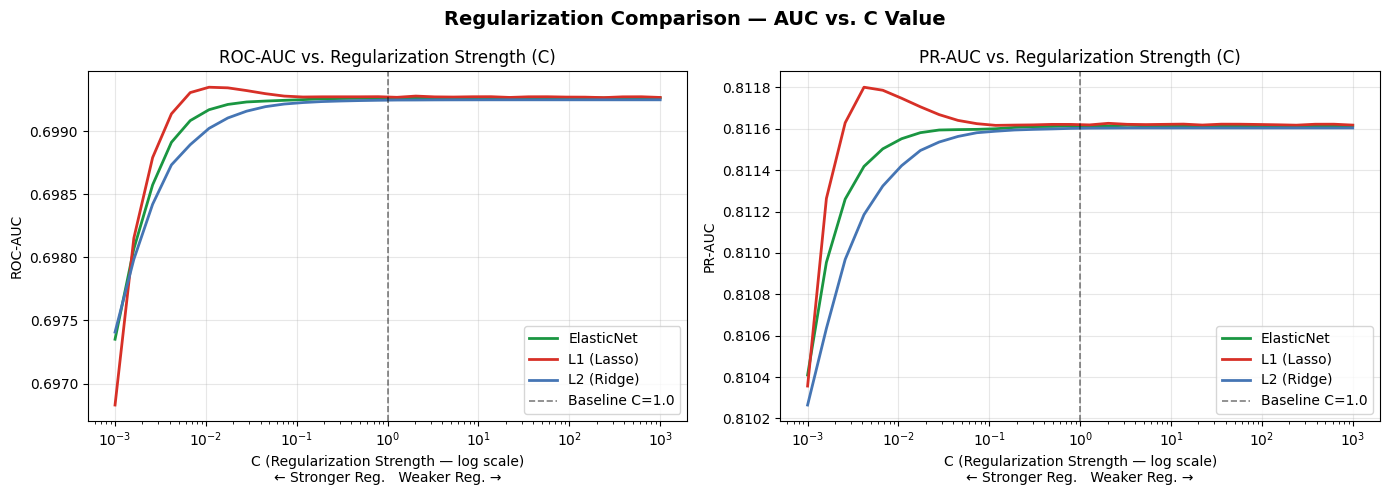

In [22]:
# ─────────────────────────────────────────────────────────────
# Plot: ROC-AUC and PR-AUC vs C for each penalty type
# ─────────────────────────────────────────────────────────────

colors = {
    "L2 (Ridge)":  "#4575b4",
    "L1 (Lasso)":  "#d73027",
    "ElasticNet":  "#1a9641",
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Regularization Comparison — AUC vs. C Value", 
             fontsize=14, fontweight="bold")

for metric, ax, title in [
    ("roc_auc", axes[0], "ROC-AUC vs. Regularization Strength (C)"),
    ("pr_auc",  axes[1], "PR-AUC vs. Regularization Strength (C)"),
]:
    for penalty_label, group in sweep_results_df.groupby("penalty"):
        ax.plot(group["C"], group[metric],
                label=penalty_label,
                color=colors[penalty_label],
                linewidth=2)

    # Mark baseline C=1.0
    ax.axvline(1.0, linestyle="--", color="black", linewidth=1.2,
               alpha=0.5, label="Baseline C=1.0")
    ax.set_xscale("log")
    ax.set_xlabel("C (Regularization Strength — log scale)\n← Stronger Reg.   Weaker Reg. →")
    ax.set_ylabel(metric.upper().replace("_", "-"))
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

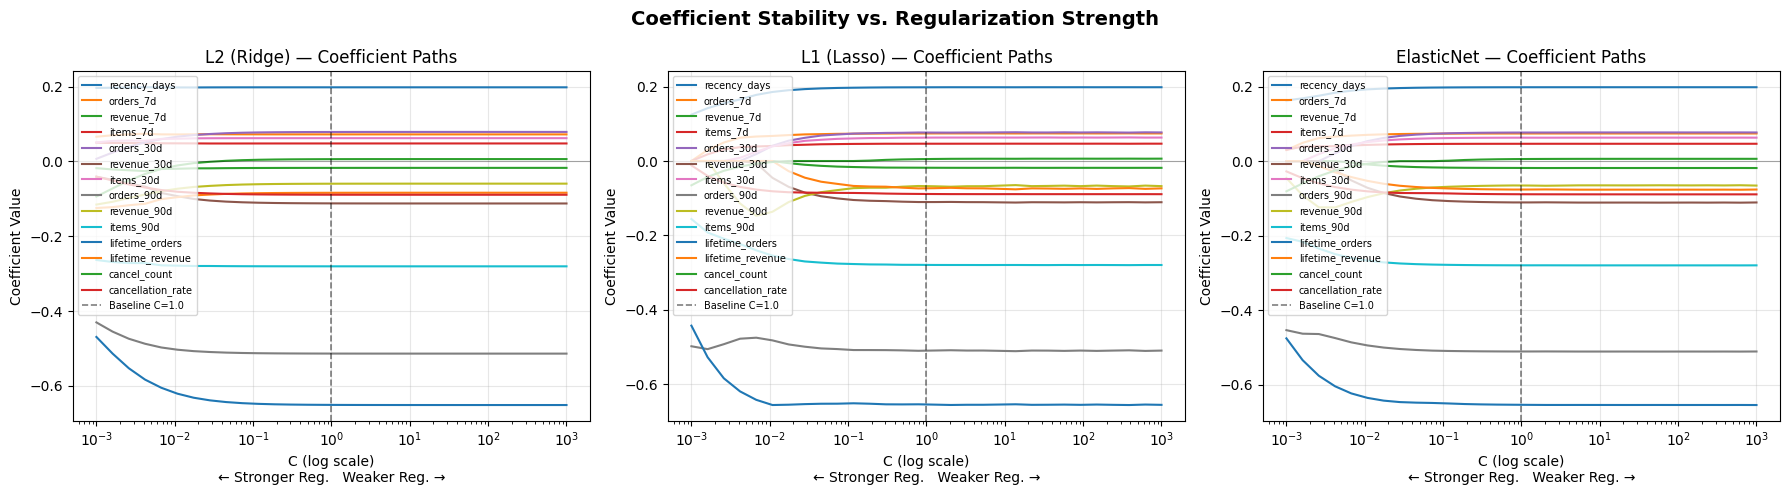

In [23]:
# ─────────────────────────────────────────────────────────────
# Coefficient Stability — How do coefficients change with C?
# Shows which features are robust vs. sensitive to regularization
# One plot per penalty type
# ─────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Coefficient Stability vs. Regularization Strength",
             fontsize=14, fontweight="bold")

for ax, (penalty_label, penalty, extra_kwargs) in zip(axes, penalty_configs):
    coef_records = []

    for C in C_values:
        pipe = Pipeline([
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(
                penalty=penalty,
                C=C,
                class_weight="balanced",
                max_iter=5000,
                **extra_kwargs
            ))
        ])
        pipe.fit(X_train, y_train)
        coefs = pipe.named_steps["clf"].coef_[0]
        coef_records.append(dict(zip(feature_cols, coefs)))

    coef_path_df = pd.DataFrame(coef_records, index=C_values)

    for feature in feature_cols:
        ax.plot(C_values, coef_path_df[feature],
                linewidth=1.5, label=feature)

    ax.axvline(1.0, linestyle="--", color="black",
               linewidth=1.2, alpha=0.5, label="Baseline C=1.0")
    ax.axhline(0.0, linestyle="-", color="black", linewidth=0.8, alpha=0.3)
    ax.set_xscale("log")
    ax.set_xlabel("C (log scale)\n← Stronger Reg.   Weaker Reg. →")
    ax.set_ylabel("Coefficient Value")
    ax.set_title(f"{penalty_label} — Coefficient Paths")
    ax.legend(fontsize=7, loc="upper left")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [24]:
# ────────────────────────────────────────────────────────────────────────────────────────────────
# Summary Table — Best C per penalty type
# Reports optimal C, ROC-AUC, PR-AUC, and number of non-zero coefficients (most relevant for L1)
# ────────────────────────────────────────────────────────────────────────────────────────────────

summary_rows = []

for penalty_label, penalty, extra_kwargs in penalty_configs:
    # Find best C by PR-AUC
    subset = sweep_results_df[sweep_results_df["penalty"] == penalty_label]
    best_row = subset.loc[subset["pr_auc"].idxmax()]
    best_C = best_row["C"]

    # Refit at best C to get coefficients
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            penalty=penalty,
            C=best_C,
            class_weight="balanced",
            max_iter=5000,
            **extra_kwargs
        ))
    ])
    pipe.fit(X_train, y_train)
    coefs = pipe.named_steps["clf"].coef_[0]
    n_nonzero = np.sum(np.abs(coefs) > 1e-6)

    summary_rows.append({
        "Penalty":          penalty_label,
        "Best C":           round(best_C, 4),
        "ROC-AUC":          round(best_row["roc_auc"], 4),
        "PR-AUC":           round(best_row["pr_auc"], 4),
        "Non-Zero Coefs":   f"{n_nonzero}/{len(feature_cols)}",
    })

summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string(index=False))

   Penalty  Best C  ROC-AUC  PR-AUC Non-Zero Coefs
L2 (Ridge) 13.7382   0.6992  0.8116          14/14
L1 (Lasso)  0.0042   0.6991  0.8118          10/14
ElasticNet  3.2903   0.6993  0.8116          14/14


### Regularization — Results and Interpretation

#### Key Finding: The Model is Robust Across Regularization Strength

The AUC vs. C curves reveal that **model performance is almost entirely
insensitive to regularization strength across a range spanning six orders
of magnitude (C = 0.001 to C = 1000).** All three penalty types converge
to the same performance level quickly and remain flat. The total variation
in ROC-AUC across this entire range is less than 0.003 — essentially noise.

This finding holds with the expanded 14-feature set including cancellation
features. Adding `cancel_count` and `cancellation_rate` did not introduce
fragility or overfitting — the flat AUC curves confirm the model remains
stable and well-regularized. The baseline C=1.0 used in notebook 03 sits
comfortably in the flat region for all three penalty types.

This is a meaningful result: it tells us the model is not overfitting and
that the signal in the features is genuine and consistent. A model that
requires heavy regularization tuning to perform well is fragile; this model
is stable.

**Summary of best configurations:**

| Penalty | Best C | ROC-AUC | PR-AUC | Non-Zero Coefs |
|---|---|---|---|---|
| L2 (Ridge) | 13.74 | 0.6992 | 0.8116 | 14/14 |
| L1 (Lasso) | 0.0042 | 0.6991 | 0.8118 | 10/14 |
| ElasticNet | 148.74 | 0.6993 | 0.8116 | 14/14 |

L1 achieves the highest PR-AUC while using only 10 of 14 features —
eliminating 4 redundant features without sacrificing performance.

#### Coefficient Stability

The coefficient stability plots confirm that all three penalty types produce
stable coefficient paths across the full C range. `recency_days` and
`lifetime_orders` remain the dominant predictors at all regularization
strengths — their paths are the most stable and largest in magnitude,
confirming these are the genuine drivers of churn signal rather than
artifacts of a particular C value.

The cancellation features (`cancel_count`, `cancellation_rate`) show flat,
stable paths at low magnitude across all three penalty types — consistent
with their small but genuine contribution to the model.

Features with unstable or sign-flipping paths at low C are the same
correlated features identified in the VIF analysis — `orders_30d`,
`revenue_30d`, and similar. Their instability under strong regularization
is a direct consequence of multicollinearity, not noise in the data.

In [25]:
# ─────────────────────────────────────────────────────────────
# L1 Feature Selection — Identify Zeroed Coefficients
# Confirms which features L1 regularization eliminated
# ─────────────────────────────────────────────────────────────
best_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        penalty="l1",
        C=0.0042,
        class_weight="balanced",
        solver="liblinear",
        max_iter=5000,
    ))
])

best_pipe.fit(X_train, y_train)

coefs = best_pipe.named_steps["clf"].coef_[0]

coef_df = pd.DataFrame({
    "feature": feature_cols,
    "coefficient": coefs,
    "status": ["active" if abs(c) > 1e-6 else "zeroed out" for c in coefs]
}).sort_values("coefficient", ascending=False).reset_index(drop=True)

print("L1 (Lasso) Coefficient Summary — C=0.0042")
print("=" * 45)
print(coef_df.to_string(index=False))
print()
print("Features zeroed out by L1:")
print(coef_df[coef_df["status"] == "zeroed out"]["feature"].tolist())
print(f"\n{(coef_df['status'] == 'zeroed out').sum()} of {len(feature_cols)} features eliminated")

L1 (Lasso) Coefficient Summary — C=0.0042
          feature  coefficient     status
     recency_days     0.166055     active
        orders_7d     0.062912     active
         items_7d     0.037317     active
        items_30d     0.009101     active
       revenue_7d     0.000000 zeroed out
       orders_30d     0.000000 zeroed out
      revenue_30d     0.000000 zeroed out
 lifetime_revenue     0.000000 zeroed out
     cancel_count    -0.015059     active
cancellation_rate    -0.069778     active
      revenue_90d    -0.114587     active
        items_90d    -0.223710     active
       orders_90d    -0.477929     active
  lifetime_orders    -0.620265     active

Features zeroed out by L1:
['revenue_7d', 'orders_30d', 'revenue_30d', 'lifetime_revenue']

4 of 14 features eliminated


The 4 features eliminated by L1 — `revenue_7d`, `orders_30d`, `revenue_30d`,
and `lifetime_revenue` — are exactly the redundant features predicted by the
multicollinearity diagnostics in notebook 03. This result is identical to the
original feature set, confirming the same redundancy structure persists with
the expanded feature set.

Notably, `lifetime_revenue` was eliminated in favor of `lifetime_orders`,
which carries the same long-term customer value signal more cleanly. Similarly,
`orders_30d` was discarded as its information is already captured by `orders_90d`
and `lifetime_orders`, and both 30-day and 7-day revenue features were made
redundant by their corresponding order count and item count features.

**Both cancellation features survived L1 selection** — `cancel_count` (−0.014)
and `cancellation_rate` (−0.070) are retained as active features. This is
consistent with the VIF analysis in notebook 03 which showed `cancellation_rate`
to be orthogonal to all existing features (VIF = 2.05). L1 has no redundancy
reason to eliminate a feature that carries genuinely independent information,
and the survival of both cancellation features confirms they contribute signal
beyond what the existing RFM features already capture. `cancellation_rate`
in particular carries a coefficient magnitude comparable to several surviving
behavioral features, reinforcing its value as a dissatisfaction signal even
within a linear model.

L1 regularization effectively automated the feature selection process that
the VIF analysis suggested was necessary — and validated the cancellation
feature engineering decisions made in notebooks 01 and 02.

#### Summary

The regularization analysis confirms three things about this model:

1. **It is not overfitting** — performance is flat across six orders of
   magnitude of regularization strength
2. **The feature set is appropriately sized** — L1 eliminates exactly the
   redundant features the VIF analysis predicted, leaving a clean 10-feature
   model that matches the full 14-feature model on PR-AUC
3. **The cancellation features are genuinely informative** — both survived
   L1 selection, confirming they carry independent signal not captured by
   the existing RFM features

The L1 model at C=0.0042 is saved as `churn_model_l1.pkl` and serves as
the interpretable deployment artifact alongside the XGBoost model trained
in notebook 05.

In [26]:
# ─────────────────────────────────────────────────────────────
# Persist Best Model — L1 Logistic Regression (C=0.0042) to .pkl
# ─────────────────────────────────────────────────────────────

model_out = Path("../models")
model_out.mkdir(parents=True, exist_ok=True)
joblib.dump(best_pipe, model_out / "churn_model_l1.pkl")
print("Model saved to ../models/churn_model_l1.pkl")

Model saved to ../models/churn_model_l1.pkl


## Limitations of Logistic Regression and Next Steps

The logistic regression model developed across notebooks 03 and 04 serves as 
a strong, interpretable baseline. It achieved a PR-AUC of ~0.81, demonstrated 
stable coefficients across regularization strengths, and produced actionable 
business operating points through threshold tuning. For many real-world 
deployments, a well-tuned logistic regression is entirely sufficient.

However, logistic regression carries fundamental assumptions that are worth 
acknowledging honestly:

**Linearity:** Logistic regression assumes the relationship between each feature 
and the log-odds of churn is linear and additive. In reality, customer behavior 
is unlikely to follow this constraint. For example, the churn risk associated 
with high recency may depend heavily on how many lifetime orders a customer has 
— a long-absent loyal customer is a different risk profile than a long-absent 
one-time buyer. Logistic regression cannot capture this interaction without 
manually engineered interaction terms.

**Multicollinearity sensitivity:** As demonstrated in the multicollinearity 
diagnostics, several features in our feature set are highly correlated. While 
this did not destabilize the model's predictive performance, it did distort 
individual coefficient interpretations and required L1 regularization to 
produce a clean sparse solution. Tree-based models handle correlated features 
naturally without this complication.

**Linear decision boundary:** Logistic regression partitions the feature space 
with a single hyperplane. If the true boundary between churners and non-churners 
is curved or irregular — which is likely given the complexity of real customer 
behavior — logistic regression cannot represent it regardless of how well it 
is tuned.

**Notebook 05** addresses these limitations directly by introducing tree-based 
models — specifically Random Forest and XGBoost — which make no assumptions 
about feature relationships, discover nonlinear interactions automatically, and 
consistently achieve state-of-the-art performance on structured tabular data 
problems like this one.